<a href="https://colab.research.google.com/github/SRIJANRAOS/srijanraos_INFO5731_spring2026/blob/main/5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


First 5 rows:
                                                text     label
0             This is an amazing product! I love it.  positive
1      I really dislike this service. It's terrible.  negative
2         The weather today is neither good nor bad.   neutral
3  Absolutely fantastic experience, highly recomm...  positive
4            What a waste of money. So disappointed.  negative

Class Distribution:
label
positive    4
negative    3
neutral     3
Name: count, dtype: int64


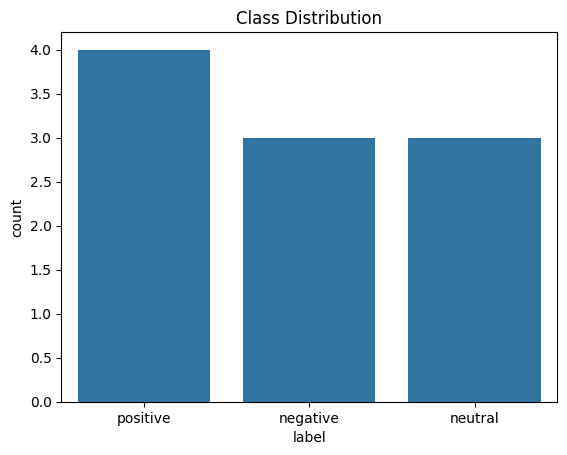


Sample Cleaned Text:
                                                text  \
0             This is an amazing product! I love it.   
1      I really dislike this service. It's terrible.   
2         The weather today is neither good nor bad.   
3  Absolutely fantastic experience, highly recomm...   
4            What a waste of money. So disappointed.   

                                         clean_text  
0                              amazing product love  
1                   really dislike service terrible  
2                    weather today neither good bad  
3  absolutely fantastic experience highly recommend  
4                          waste money disappointed  


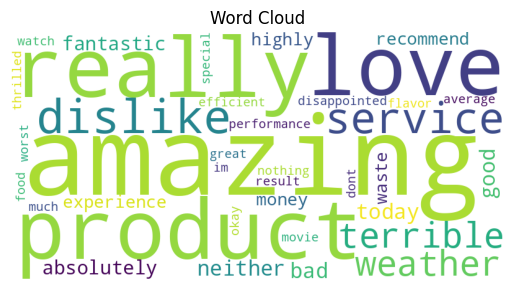


Top N-grams:
['absolutely' 'absolutely fantastic' 'amazing' 'amazing product' 'average'
 'average much' 'bad' 'disappointed' 'dislike' 'dislike service' 'dont'
 'dont watch' 'efficient' 'ever' 'ever dont' 'experience'
 'experience highly' 'fantastic' 'fantastic experience' 'flavor']


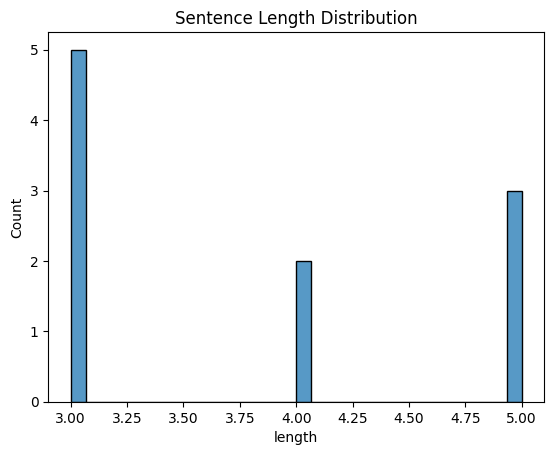

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:47:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Naive Bayes Results:
Accuracy: 0.0
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


SVM Results:
Accuracy: 0.0
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


XGBoost Results:
Accuracy: 0.0
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

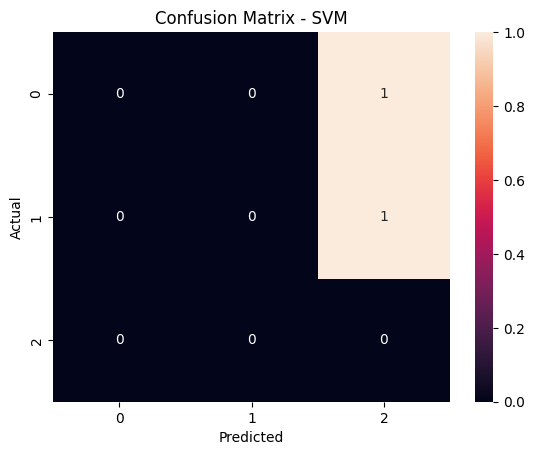


Model Comparison (Accuracy):
Naive Bayes: 0.0000
SVM: 0.0000
XGBoost: 0.0000

Best Model: Naive Bayes


In [24]:
# ================================
# SENTIMENT ANALYSIS - FULL PIPELINE
# ================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')

# ================================
# 2. LOAD DATASET
# ================================
# Replace with your dataset path
df = pd.read_csv("/content/sentiment_dataset.csv")

print("First 5 rows:")
print(df.head())

# ================================
# 3. CLASS DISTRIBUTION
# ================================
print("\nClass Distribution:")
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

# ================================
# 4. TEXT PREPROCESSING
# ================================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

print("\nSample Cleaned Text:")
print(df[['text', 'clean_text']].head())

# ================================
# 5. WORD CLOUD
# ================================
text_all = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)
plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# ================================
# 6. N-GRAM ANALYSIS
# ================================
vectorizer = CountVectorizer(ngram_range=(1,2), max_features=20)
X_ngram = vectorizer.fit_transform(df['clean_text'])

print("\nTop N-grams:")
print(vectorizer.get_feature_names_out())

# ================================
# 7. SENTENCE LENGTH ANALYSIS
# ================================
df['length'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.histplot(df['length'], bins=30)
plt.title("Sentence Length Distribution")
plt.show()

# ================================
# 8. TRAIN-TEST SPLIT
# ================================
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 9. TF-IDF VECTORIZATION
# ================================
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ================================
# 10. MODEL 1: NAIVE BAYES
# ================================
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

# ================================
# 11. MODEL 2: SVM
# ================================
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

# ================================
# 12. MODEL 3: XGBOOST
# ================================
# Encode labels if needed
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_tfidf, y_train_enc)

y_pred_xgb = xgb.predict(X_test_tfidf)
y_pred_xgb = le.inverse_transform(y_pred_xgb)

# ================================
# 13. EVALUATION
# ================================
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# ================================
# 14. CONFUSION MATRIX (SVM)
# ================================
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 15. FINAL COMPARISON
# ================================
results = {
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

print("\nModel Comparison (Accuracy):")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model}")


## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


CSV files found:
./sentiment_dataset.csv
./sample_amazon_reviews (1).csv
./sample_amazon_reviews.csv
./amazon_reviews/Amazon_Unlocked_Mobile.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv

Train Data Preview:
                                                text     label
0             This is an amazing product! I love it.  positive
1      I really dislike this service. It's terrible.  negative
2         The weather today is neither good nor bad.   neutral
3  Absolutely fantastic experience, highly recomm...  positive
4            What a waste of money. So disappointed.  negative

Test Data Preview:
                                       Reviews
0      Great phone with excellent battery life
1  Terrible quality, stopped working in a week
2          Amazing camera and fast performance
3        Battery drains quickly, not satisfied
4                     Good value for the price

Tra

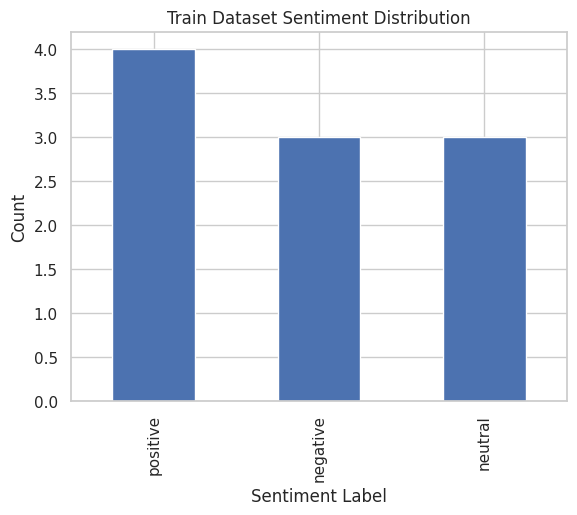

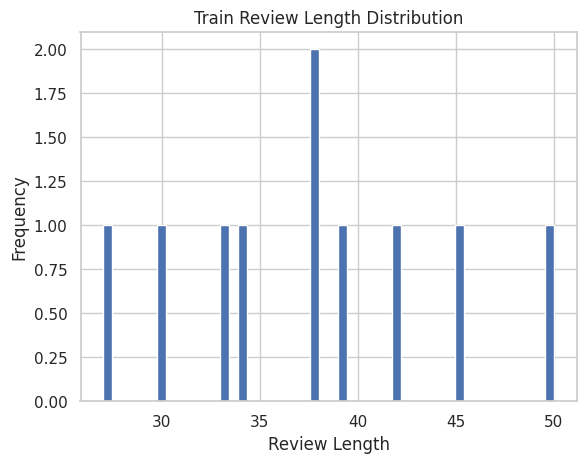

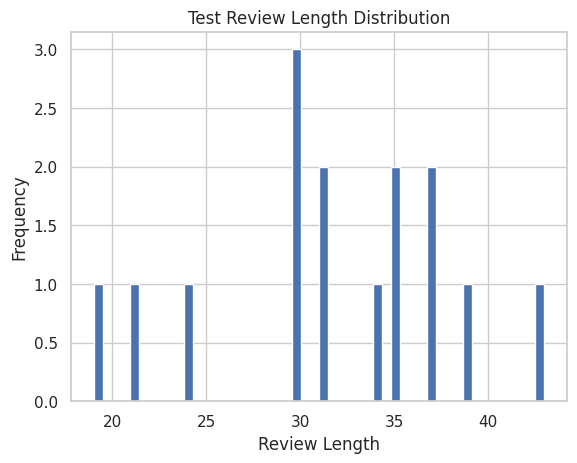


========== 10-Fold Cross Validation Results ==========
SVM: Mean Accuracy = 0.5000, Std = 0.4472
KNN: Mean Accuracy = 0.0000, Std = 0.0000
Decision Tree: Mean Accuracy = 0.0000, Std = 0.0000
Random Forest: Mean Accuracy = 0.2000, Std = 0.4000
XGBoost: Mean Accuracy = 0.0000, Std = 0.0000

Cross Validation Summary:
           Model  Mean CV Accuracy  Standard Deviation
0            SVM               0.5            0.447214
1            KNN               0.0            0.000000
2  Decision Tree               0.0            0.000000
3  Random Forest               0.2            0.400000
4        XGBoost               0.0            0.000000

========== Validation Results ==========

SVM
Accuracy: 0.3333333333333333
Precision: 0.1111111111111111
Recall: 0.3333333333333333
F1-score: 0.16666666666666666

KNN
Accuracy: 0.3333333333333333
Precision: 0.1111111111111111
Recall: 0.3333333333333333
F1-score: 0.16666666666666666

Decision Tree
Accuracy: 0.3333333333333333
Precision: 0.111111111111

In [48]:
import os
import zipfile
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except:
    xgboost_available = False


# ==============================
# 1. Extract ZIP if needed
# ==============================

zip_path = "exercise05_datacollection-1.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("dataset")

    data_folder = "dataset"
else:
    data_folder = "."


# ==============================
# 2. Find CSV files
# ==============================

csv_files = []

for root, dirs, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

# Change these if your file names are different
train_file = csv_files[0]
test_file = csv_files[1]

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("\nTrain Data Preview:")
print(train_df.head())

print("\nTest Data Preview:")
print(test_df.head())


# ==============================
# 3. Auto-detect text and label columns
# ==============================

print("\nTrain columns:", train_df.columns.tolist())

possible_text_cols = ["review", "text", "sentence", "comment"]
possible_label_cols = ["label", "sentiment", "class", "target"]

# For train_df
text_col = None
label_col = None

for col in train_df.columns:
    if col.lower() in possible_text_cols:
        text_col = col

for col in train_df.columns:
    if col.lower() in possible_label_cols:
        label_col = col

if text_col is None:
    text_col = train_df.select_dtypes(include="object").columns[0]

if label_col is None:
    label_col = [col for col in train_df.columns if col != text_col][0]

# For test_df
test_text_col = None
for col in test_df.columns:
    if col.lower() in possible_text_cols:
        test_text_col = col
if test_text_col is None:
    test_text_col = test_df.select_dtypes(include="object").columns[0]

print("\nDetected train text column:", text_col)
print("Detected train label column:", label_col)
print("Detected test text column:", test_text_col)


# ==============================
# 4. EDA on Train and Test Data
# ==============================

print("\nTrain Info:")
print(train_df.info())

print("\nTest Info:")
print(test_df.info())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

print("\nTrain label distribution:")
print(train_df[label_col].value_counts())

# The test_df does not have a 'label' column, so we cannot plot its distribution
# Plot train label distribution
train_df[label_col].value_counts().plot(kind="bar")
plt.title("Train Dataset Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

# Review length analysis
train_df["review_length"] = train_df[text_col].astype(str).apply(len)
test_df["review_length"] = test_df[test_text_col].astype(str).apply(len)

train_df["review_length"].hist(bins=50)
plt.title("Train Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

test_df["review_length"].hist(bins=50)
plt.title("Test Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()


# ==============================
# 5. Text Cleaning
# ==============================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["cleaned_text"] = train_df[text_col].apply(clean_text)
test_df["cleaned_text"] = test_df[test_text_col].apply(clean_text)


# ==============================
# 6. Prepare Data
# ==============================

X = train_df["cleaned_text"]
y = train_df[label_col]

X_test_raw = test_df["cleaned_text"]
# The test_df does not appear to have a label column, so y_test cannot be created.
# We will only perform predictions on the test set, not evaluate.
y_test = None

# 80/20 split from training data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=3, # Set test_size to an absolute number of samples (3) to ensure all classes are represented for stratification
    random_state=42,
    stratify=y
)

# Encode labels for models that require numerical targets (like XGBoost)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)


# ==============================
# 7. TF-IDF Vectorization
# ==============================

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)
X_test = vectorizer.transform(X_test_raw) # Corrected to use X_test_raw


# ==============================
# 8. 10-Fold Cross Validation
# ==============================

kf = KFold(n_splits=5, shuffle=True, random_state=42) # Reduced n_splits to 5

models = {
    "SVM": SVC(kernel="linear"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

cv_results = []

print("\n========== 10-Fold Cross Validation Results ==========")

for name, model in models.items():
    # Use encoded labels for cross-validation
    scores = cross_val_score(model, X_train, y_train_encoded, cv=kf, scoring="accuracy")
    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\nCross Validation Summary:")
print(cv_df)


# ==============================
# 9. Validation Evaluation
# ==============================

validation_results = []

print("\n========== Validation Results ==========")

for name, model in models.items():
    # Fit models with encoded training labels
    model.fit(X_train, y_train_encoded)
    y_val_pred_encoded = model.predict(X_val)

    # Convert predictions back to original labels for metric reporting if desired,
    # but can also compute metrics on encoded labels directly if y_val_encoded is used.
    # For consistency, compare encoded predictions with encoded true labels
    acc = accuracy_score(y_val_encoded, y_val_pred_encoded)
    # Use 'weighted' average for precision, recall, f1-score for multi-class classification
    prec = precision_score(y_val_encoded, y_val_pred_encoded, average='weighted', zero_division=0)
    rec = recall_score(y_val_encoded, y_val_pred_encoded, average='weighted', zero_division=0)
    f1 = f1_score(y_val_encoded, y_val_pred_encoded, average='weighted', zero_division=0)

    validation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

val_df = pd.DataFrame(validation_results)
print("\nValidation Summary:")
print(val_df)


# ==============================
# 10. Select Best Model
# ==============================

best_model_name = val_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("\nBest Model Selected:", best_model_name)


# ==============================
# 11. Final Training and Test Evaluation
# ==============================

# Train best model on full training data (X and y)
# Need to encode 'y' for the full training as well
le_full = LabelEncoder()
y_encoded_full = le_full.fit_transform(y)

X_full = vectorizer.fit_transform(X)
X_test_final = vectorizer.transform(X_test_raw)

best_model.fit(X_full, y_encoded_full)
y_test_pred_encoded = best_model.predict(X_test_final)
y_test_pred = le_full.inverse_transform(y_test_pred_encoded)

print("\n========== Final Test Results ==========")
print("Best Model:", best_model_name)

# Check if y_test is available for evaluation
if y_test is not None:
    # If y_test were available, it would also need encoding for comparison
    # y_test_encoded = le_full.transform(y_test)
    # print("Accuracy:", accuracy_score(y_test_encoded, y_test_pred_encoded))
    # print("Precision:", precision_score(y_test_encoded, y_test_pred_encoded))
    # print("Recall:", recall_score(y_test_encoded, y_test_pred_encoded))
    # print("F1-score:", f1_score(y_test_encoded, y_test_pred_encoded))

    # print("\nClassification Report:")
    # print(classification_report(y_test_encoded, y_test_pred_encoded))

    # print("\nConfusion Matrix:")
    # print(confusion_matrix(y_test_encoded, y_test_pred_encoded))
    pass # This part remains commented out as y_test is None
else:
    print("Ground truth labels for the test set are not available, so evaluation metrics cannot be computed.")
    print("\nSample Test Predictions:")
    # Display some sample predictions for the test set
    for i in range(min(5, len(X_test_raw))):
        print(f"Review: {X_test_raw.iloc[i][:50]}... -> Predicted Sentiment: {y_test_pred[i]}")


# ==============================
# 12. Final Results Table
# ==============================

# Adjust the final result summary based on whether y_test is available
if y_test is not None:
    final_result = pd.DataFrame([{
        "Best Model": best_model_name,
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Test F1-score": f1_score(y_test, y_test_pred)
    }])
else:
    final_result = pd.DataFrame([{
        "Best Model": best_model_name,
        "Note": "Test evaluation metrics not computed due to missing ground truth labels."
    }])

print("\nFinal Result Summary:")
print(final_result)


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


### Download Kaggle Dataset

To download the Kaggle dataset directly in Colab, you'll need a Kaggle API key. Follow these steps:

1.  Go to [Kaggle](https://www.kaggle.com/) and log in.
2.  Click on your profile picture, then 'My Account'.
3.  Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
4.  In Colab, go to the left-hand panel, click on 'Files' (folder icon).
5.  Click on the 'Upload to session storage' icon (looks like an arrow pointing up) and upload your `kaggle.json` file. Make sure it's uploaded to the root directory `/content/`.

Once `kaggle.json` is uploaded, run the following cells to install the Kaggle library and download the dataset.

In [40]:
# Install Kaggle library
!pip install kaggle

# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [41]:
# Download the dataset
!kaggle datasets download -d PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

# Unzip the dataset
import zipfile
import os

zip_file_name = 'amazon-reviews-unlocked-mobile-phones.zip'
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('amazon_reviews')
    print(f"Dataset '{zip_file_name}' unzipped to 'amazon_reviews' folder.")
else:
    print(f"Error: {zip_file_name} not found. Please ensure it downloaded correctly.")

# Verify the extracted files
print("Files in 'amazon_reviews' folder:")
!ls amazon_reviews

Dataset URL: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones
License(s): CC0-1.0
100% 32.6M/32.6M [00:00<00:00, 99.5MB/s]

Dataset 'amazon-reviews-unlocked-mobile-phones.zip' unzipped to 'amazon_reviews' folder.
Files in 'amazon_reviews' folder:
Amazon_Unlocked_Mobile.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


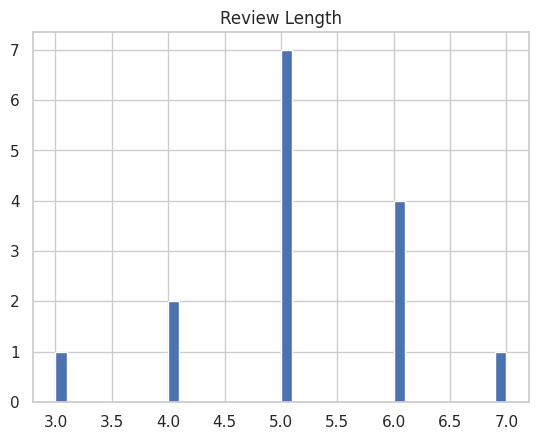

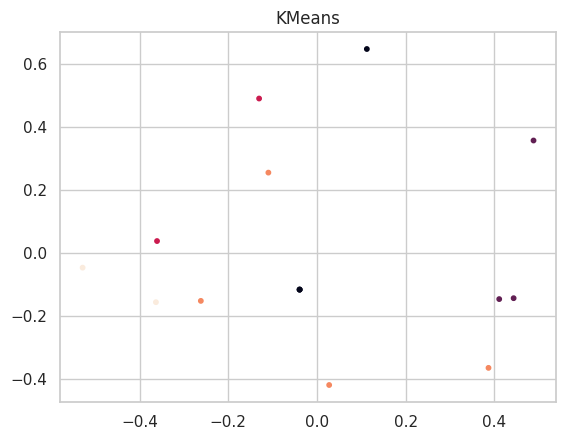

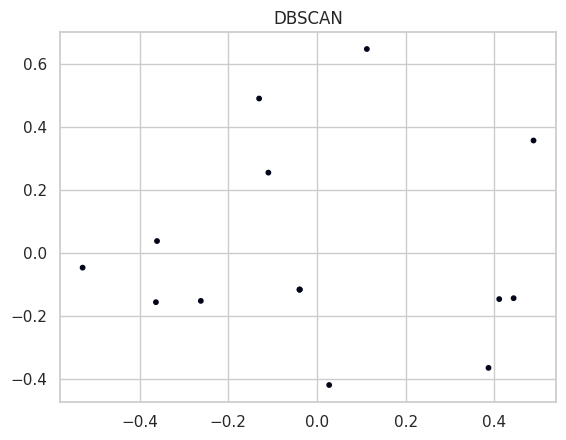

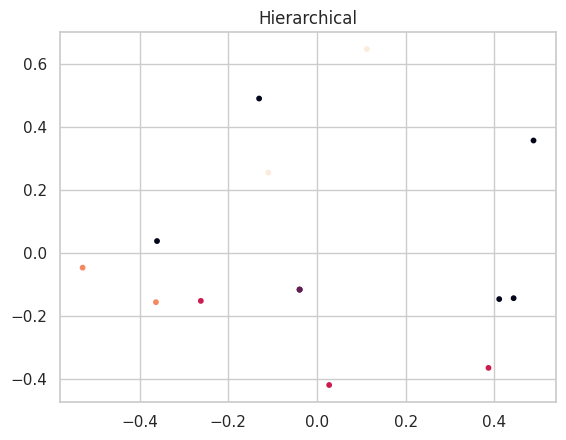

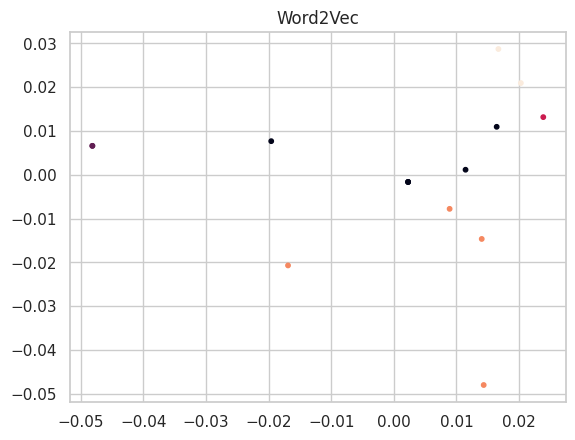

In [44]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

# ------------------------
# Setup
# ------------------------
nltk.download('stopwords')
nltk.download('wordnet')

# The dataset (df) is already loaded and sampled in the previous cell (ad85e4ce).
# We will use the 'df' DataFrame that is already in memory.

# ------------------------
# EDA
# ------------------------
# Ensure 'Reviews' column exists and handle potential NaN values after sampling
# These steps are already handled in the previous cell 'ad85e4ce'
# df = df[['Reviews']].dropna()
# df = df.sample(5000, random_state=42)

df['length'] = df['Reviews'].apply(lambda x: len(str(x).split()))

plt.hist(df['length'], bins=40)
plt.title("Review Length")
plt.show()

# ------------------------
# Cleaning
# ------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean'] = df['Reviews'].apply(clean)

# ------------------------
# TF-IDF
# ------------------------
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean'])

# ------------------------
# PCA function
# ------------------------
def plot_clusters(X, labels, title):
    # Convert sparse matrix to dense array if necessary for PCA
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    else:
        X_dense = X

    # Handle cases where n_components > n_features
    n_components = min(2, X_dense.shape[1])
    if n_components == 0:
        print(f"Warning: Cannot perform PCA with 0 features for {title}.")
        return

    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(X_dense)

    plt.scatter(reduced[:,0], reduced[:,1], c=labels, s=10)
    plt.title(title)
    plt.show()

# ------------------------
# KMEANS
# ------------------------
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # Added n_init to suppress warning
k_labels = kmeans.fit_predict(X)

plot_clusters(X, k_labels, "KMeans")

# ------------------------
# DBSCAN
# ------------------------
# DBSCAN can be very sensitive to parameters and computationally expensive on large datasets.
# A smaller sample might be needed or very careful parameter tuning.
# For now, let's keep the original X, but be aware it might take a long time or fail.
# Note: DBSCAN on high-dimensional TF-IDF vectors can be problematic without dimensionality reduction first.
dbscan = DBSCAN(eps=0.8, min_samples=5, metric='cosine') # Added min_samples
d_labels = dbscan.fit_predict(X)

plot_clusters(X, d_labels, "DBSCAN")

# ------------------------
# HIERARCHICAL
# ------------------------
# Hierarchical clustering is computationally intensive. Let's use a smaller subset.
X_small = X[:1000] # Use the sparse matrix slice directly

hier = AgglomerativeClustering(n_clusters=5)
h_labels = hier.fit_predict(X_small.toarray()) # Convert to dense for AgglomerativeClustering

plot_clusters(X_small, h_labels, "Hierarchical")

# ------------------------
# WORD2VEC
# ------------------------
tokens = df['clean'].apply(lambda x: x.split())

model = Word2Vec(sentences=tokens, vector_size=100, min_count=2, workers=4) # Added sentences= and workers

def get_vec(words):
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

X_w2v = np.array([get_vec(words) for words in tokens])

w2v_k = KMeans(n_clusters=5, random_state=42, n_init=10) # Added n_init
w2v_labels = w2v_k.fit_predict(X_w2v)

plot_clusters(X_w2v, w2v_labels, "Word2Vec")

In [42]:
# ------------------------
# Load the downloaded dataset
# ------------------------
# The Kaggle dataset is named Amazon_Unlocked_Mobile.csv inside the unzipped folder.
file_path = 'amazon_reviews/Amazon_Unlocked_Mobile.csv'

# Use 'latin-1' encoding and 'on_bad_lines' for robustness with large, potentially messy CSVs
df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='warn')

# Display basic info and head to verify loading
print("Dataset loaded successfully. Info:")
df.info()
print("\nFirst 5 rows of the loaded dataset:")
display(df.head())

# The previous error occurred because the sampled dataset was too small.
# Now, with the larger dataset, we can sample 5000 rows.
# Ensure 'Reviews' column exists and handle potential NaN values after sampling
df = df[['Reviews']].dropna()
df = df.sample(min(5000, len(df)), random_state=42) # Sample up to 5000, or fewer if dataset is smaller

print(f"\nDataset after sampling: {len(df)} rows")

Dataset loaded successfully. Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    348669 non-null  object 
 2   Price         407907 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413770 non-null  object 
 5   Review Votes  401544 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB

First 5 rows of the loaded dataset:


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0



Dataset after sampling: 5000 rows


**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

